# Dataset19 — Step 2: Remove the CFO from the switched I/Q samples

Step 1 measured, for every packet, the frequency offset $\Delta f$ between the received CTE tone and the receiver's local oscillator, as a unit phasor $\rho = e^{\,j2\pi\Delta f T_s}$ from the eight reference samples IQ1–IQ8 (all on ANT1).

This notebook uses $\rho$ to strip that rotation out of the other 74 samples, IQ9–IQ82, which were taken while the receiver switched through the sixteen antennas. At the end each packet yields three 16-antenna **snapshots** — the input to MUSIC in Step 3.

Sections:

1. Load the dataset (same as Step 1, condensed)
2. Timing and antenna map of the 82 samples
3. What a switched sample contains, and why it must be corrected
4. The correction $\tilde z_k = z_k\,\bar\rho^{\,t_k/T_s}$ — worked on one packet
5. Verifying the correction: the repeated-antenna test, on one packet and on the whole dataset
6. Building snapshots: order by antenna, reference to ANT1
7. Save snapshots for Step 3

## 1. Load the dataset

Identical to Step 1: download/unzip, parse `setup.txt`, load every `setN.csv`, and compute $\rho$ per packet. The functions are repeated here so this notebook runs on its own.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.simplefilter('ignore', pd.errors.PerformanceWarning)

import zipfile, urllib.request

DATA_URL  = ('https://github.com/githubdcw/EEKU-Bluetooth-Locationing/'
             'raw/refs/heads/main/data/Dataset19.zip')
ZIP_PATH  = Path('Dataset19.zip')   # downloaded next to this notebook
DATA_ROOT = Path('Dataset19')       # folder the zip extracts to (zip already contains Dataset19/)

if not ZIP_PATH.exists():
    print(f'downloading {DATA_URL} ...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print(f'saved {ZIP_PATH} ({ZIP_PATH.stat().st_size/1e6:.1f} MB)')
else:
    print(f'{ZIP_PATH} already present, skipping download')

if not DATA_ROOT.exists():
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(ZIP_PATH.parent)
    print(f'extracted {ZIP_PATH} -> {DATA_ROOT}/')
else:
    print(f'{DATA_ROOT}/ already exists, skipping extraction')

csvs = sorted(p.name for p in DATA_ROOT.glob('*.csv'))
print(csvs)
if 'set7.csv' not in csvs:
    print('WARNING: this copy has only', len(csvs), 'CSVs; the current Dataset19 has set1-set7 + test')

Dataset19.zip already present, skipping download
Dataset19/ already exists, skipping extraction
['set1.csv', 'set2.csv', 'set3.csv', 'set4.csv', 'set5.csv', 'set6.csv', 'set7.csv', 'test.csv']


In [2]:
def parse_setup19(path):
    text = Path(path).read_text().splitlines()

    # --- grid rows: contiguous lines made only of (n) tokens
    tok = re.compile(r'\(\s*(\d+)\s*\)')
    rows = []
    for line in text:
        s = line.strip()
        if s and tok.sub('', s).strip() == '':
            rows.append([int(n) for n in tok.findall(s)])
        elif rows:
            break
    nr, nc = len(rows), len(rows[0])
    assert all(len(r) == nc for r in rows), 'grid must be rectangular'

    # --- spacing and range
    G = float(re.search(r'Grid.*?=\s*([\d.]+)\s*cm', '\n'.join(text), re.I).group(1))
    m = re.search(r'Ant and\s*\(\s*(\d+)\s*\)\s*=\s*([\d.]+)\s*cm', '\n'.join(text), re.I)
    centre_pt, d = int(m.group(1)), float(m.group(2))

    # --- positions and ground truth for every grid point
    grid_xyz, grid_azel = {}, {}
    for ri, row in enumerate(rows):
        for ci, pt in enumerate(row):
            x, y, z = d, ((nc-1)/2 - ci)*G, ((nr-1)/2 - ri)*G
            grid_xyz[pt] = (x, y, z)
            grid_azel[pt] = (np.degrees(np.arctan2(y, x)),
                             np.degrees(np.arctan2(z, np.hypot(x, y))))
    assert grid_xyz[centre_pt][1:] == (0.0, 0.0), 'range must be stated to the grid centre'

    # --- reference points
    ref_line = next(l for l in text if 'reference' in l.lower())
    ref_pts = [int(n) for n in tok.findall(ref_line)]

    # --- per-set MAC suffix -> grid point   (blocks "set1:", "test.csv:")
    sets, cur = {}, None
    for line in text:
        s = line.strip()
        m = re.match(r'^(\w+(?:\.csv)?):\s*$', s)
        if m:
            cur = m.group(1).replace('.csv', ''); sets[cur] = {}; continue
        m = re.match(r'^\(\s*(\d+)\s*\)\s*([0-9A-Fa-f]{2}:[0-9A-Fa-f]{2})$', s)
        if m and cur:
            sets[cur][m.group(2).lower()] = int(m.group(1))

    return dict(d=d, G=G, nr=nr, nc=nc, centre_pt=centre_pt, ref_pts=ref_pts,
                grid_xyz=grid_xyz, grid_azel=grid_azel, sets=sets)

cfg = parse_setup19(DATA_ROOT / 'setup.txt')
print(f"grid {cfg['nr']}x{cfg['nc']}, G = {cfg['G']} cm, d = {cfg['d']} cm, centre = pt{cfg['centre_pt']}")
print('reference points:', cfg['ref_pts'])
print('sets:', {k: len(v) for k, v in cfg['sets'].items()})

grid 7x7, G = 40.0 cm, d = 295.0 cm, centre = pt25
reference points: [1, 4, 7, 15, 21, 25, 29, 35, 43, 46, 49]
sets: {'test': 11, 'set1': 15, 'set2': 15, 'set3': 15, 'set4': 15, 'set5': 15, 'set6': 15, 'set7': 15}


In [3]:
def load_set(name):
    df = pd.read_csv(DATA_ROOT / f'{name}.csv')
    df['set'] = name
    df['suffix'] = df['address'].str[-5:].str.lower()
    df['pt'] = df['suffix'].map(cfg['sets'][name])
    unknown = df.loc[df['pt'].isna(), 'address'].unique()
    assert len(unknown) == 0, f'{name}: MACs not in setup.txt: {unknown}'
    df['pt'] = df['pt'].astype(int)
    return df

frames = {name: load_set(name) for name in cfg['sets']}
df = pd.concat(frames.values(), ignore_index=True)

summary = df.groupby(['set', 'pt']).size().unstack('set').fillna(0).astype(int)
summary.index.name = 'pt'
summary

set,set1,set2,set3,set4,set5,set6,set7,test
pt,,,,,,,,
1,576,408,777,732,343,454,787,573
4,695,365,303,573,1878,1337,260,128
7,682,303,236,237,895,522,627,180
8,0,350,0,0,0,0,0,0
11,0,0,0,501,708,0,0,0
13,447,0,0,224,0,0,0,0
14,0,303,0,1138,0,0,0,0
15,775,1192,1435,766,384,450,403,193
18,0,314,0,1018,472,0,0,0


In [4]:
IQ_COLS_I = [f'i{k}' for k in range(1, 83)]
IQ_COLS_Q = [f'q{k}' for k in range(1, 83)]

# Z: (N_packets, 82) complex array of all samples
Z = df[IQ_COLS_I].to_numpy(float) + 1j * df[IQ_COLS_Q].to_numpy(float)

# rho per packet from the reference period (Step 1)
prod = np.conj(Z[:, :7]) * Z[:, 1:8]
rho  = np.mean(prod / np.abs(prod), axis=1)
df['cfo_kHz']  = np.angle(rho) / (2*np.pi*1e-6) / 1e3
df['cfo_gamma'] = np.abs(rho)
print(f'{len(df)} packets, Z shape {Z.shape}, median CFO {df.cfo_kHz.median():.1f} kHz')

73000 packets, Z shape (73000, 82), median CFO -205.3 kHz


## 2. Timing and antenna map of the 82 samples

The EFR32 records 82 I/Q pairs per CTE. The first eight are 1 µs apart, all on ANT1. From IQ9 onward the receiver switches antenna every 2 µs and takes one sample per antenna:

$$ t_k = \begin{cases} (k-1)\,T_s & 1 \le k \le 8 \\ 8T_s + 2(k-9)T_s & 9 \le k \le 82 \end{cases}
\qquad
\mathrm{ant}(k) = \begin{cases} 1 & k \le 8 \\ k-7 & 9 \le k \le 23 \\ ((k-24) \bmod 16) + 1 & k \ge 24 \end{cases} $$

The switching pattern starts at ANT2 right after the reference period and then cycles ANT1→ANT16. That gives five sweeps, three of them complete:

| Samples | Time (µs) | Antennas | Use |
|---|---|---|---|
| IQ1–8 | 0–7 | ANT1 only | reference period (Step 1) |
| IQ9–23 | 8–36 | ANT2…ANT16 | G1, incomplete |
| IQ24–39 | 38–68 | ANT1…ANT16 | **G2** |
| IQ40–55 | 70–100 | ANT1…ANT16 | **G3** |
| IQ56–71 | 102–132 | ANT1…ANT16 | **G4** |
| IQ72–82 | 134–154 | ANT1…ANT11 | G5, incomplete |

The map below is the one used on every previous dataset from this board. Section 5 contains the test that would catch a different firmware switching pattern.

In [5]:
T_S = 1e-6

def slot_time_us(k):
    return (k - 1) * 1.0 if k <= 8 else 8.0 + 2.0 * (k - 9)

def slot_ant(k):
    if k <= 8:  return 1
    if k <= 23: return k - 7
    return (k - 24) % 16 + 1

K    = np.arange(1, 83)
T_US = np.array([slot_time_us(k) for k in K])       # µs, integer-valued
ANT  = np.array([slot_ant(k) for k in K])

GROUPS = {'G1': range(9, 24), 'G2': range(24, 40), 'G3': range(40, 56),
          'G4': range(56, 72), 'G5': range(72, 83)}

# show the map for the first few and the group boundaries
pd.DataFrame({'k': K, 't_us': T_US, 'ant': ANT}).set_index('k').loc[[1, 8, 9, 10, 23, 24, 25, 39, 40, 55, 56, 71, 72, 82]].T

k,1,8,9,10,23,24,25,39,40,55,56,71,72,82
t_us,0.0,7.0,8.0,10.0,36.0,38.0,40.0,68.0,70.0,100.0,102.0,132.0,134.0,154.0
ant,1.0,1.0,2.0,3.0,16.0,1.0,2.0,16.0,1.0,16.0,1.0,16.0,1.0,11.0


## 3. What a switched sample contains

From Step 1 (Background A), the baseband sample on antenna $n$ at time $t$ is

$$ z_n(t) = A_n\, e^{\,j\left(2\pi\,\Delta f\, t + \phi_0 + \psi_n\right)} $$

- $2\pi\Delta f\,t$ — rotation caused by the frequency offset; depends only on **when** the sample was taken.
- $\phi_0$ — a constant for the packet, same on every antenna. No angle information; removed later by referencing to ANT1.
- $\psi_n$ — the **spatial phase** of antenna $n$ (extra path length to that element). This is what encodes direction of arrival and what MUSIC needs.

Each antenna is visited at a different time, so the term $2\pi\Delta f\,t_k$ is different for every antenna. Between two consecutive switched samples (2 µs apart) it changes by $2\angle\rho$:

In [6]:
step_deg = np.degrees(np.angle(rho**2))            # 2·∠ρ, wrapped to ±180°
print(f'phase advance per 2 µs switch:  median {np.median(step_deg):.1f}°,  range {step_deg.min():.1f}° … {step_deg.max():.1f}°')
print(f'largest possible spatial phase between neighbouring antennas: ±{360*0.32:.0f}°   (2π·d/λ with d/λ = 0.32)')

phase advance per 2 µs switch:  median -147.8°,  range -174.8° … 179.1°
largest possible spatial phase between neighbouring antennas: ±115°   (2π·d/λ with d/λ = 0.32)


The time term (≈ −148° per switch) is larger than the biggest spatial phase difference the array can produce (±115° between neighbours, and usually far less). Without correction the phase pattern across the array is a time ramp, not a spatial one. Here it is on one packet:

In [7]:
p = df.index[df.set == 'set1'][0]      # set1 packet 0, same packet as in Step 1
z = Z[p]
print(f"packet {p}: tag {df.address[p]} (pt{df.pt[p]}), channel {df.channel[p]}, ∠ρ = {np.degrees(np.angle(rho[p])):.2f}°\n")
print("raw phases of G2 (IQ24..39) in antenna order ANT1..ANT16:")
print(np.round(np.degrees(np.angle(z[23:39])), 1))

packet 3000: tag 84:2e:14:31:ba:9e (pt46), channel 24, ∠ρ = -74.18°

raw phases of G2 (IQ24..39) in antenna order ANT1..ANT16:
[ 109.9  -85.5  110.8  -30.  -112.    36.6 -106.1    0.    92.8 -168.2
   59.3  128.3  142.1  -44.   117.3  -55.6]


## 4. The correction

$\rho$ is the rotation per microsecond, so the rotation accumulated by time $t_k$ is $\rho^{\,t_k/T_s}$. Multiplying by its conjugate undoes it:

$$ \boxed{\;\tilde z_k = z_k \cdot \bar\rho^{\,t_k/T_s}\;} \qquad\Longrightarrow\qquad \tilde z_k = A_{\mathrm{ant}(k)}\, e^{\,j(\phi_0 + \psi_{\mathrm{ant}(k)})} $$

Every sample is rotated back to what it would have been at $t = 0$. Since $t_k/T_s$ is an integer (0…7, then 8, 10, 12, …, 154) this is repeated multiplication by $\bar\rho$, and because $|\rho| = 1$ the amplitudes are untouched.

One implementation detail: the circular mean $\rho$ from Step 1 has $|\rho| = \gamma \le 1$ (0.9998 typically). Raising it to the 154th power would scale the last sample by $\gamma^{154}$ — a 3% amplitude error for $\gamma = 0.9998$, and far worse on a noisy packet. So the phasor is normalised to unit modulus before use; only its angle carries information.

### Why $\rho$ cannot be estimated from the switched samples

Two reasons. (a) They are 2 µs apart, so a phase step between them fixes the frequency only modulo 500 kHz — an unambiguous range of ±250 kHz. The true offset (≈ −206 kHz, ±15 kHz between tags) sits near that edge and would alias for some tags; the 1 µs reference period gives ±500 kHz. (b) Consecutive switched samples are on different antennas, so their phase step mixes $\psi_m - \psi_n$ with the frequency term.

In [8]:
def cfo_remove(Z, rho):
    """Z: (N, 82) complex, rho: (N,) phasors. Returns de-rotated samples, same shape."""
    rho_unit = rho / np.abs(rho)          # keep only the angle: |rho| < 1 raised to the 154th power would shrink amplitudes
    return Z * np.conj(rho_unit)[:, None] ** T_US[None, :]

Zc = cfo_remove(Z, rho)

# amplitude check: |z| must be unchanged
print('max |amplitude change| over all samples:', np.abs(np.abs(Zc) - np.abs(Z)).max())

max |amplitude change| over all samples: 6.124878382252064e-12


### Worked example — ANT1…ANT4 in every sweep

Same packet as Step 1. For each of the five sweeps, the four samples on ANT1–ANT4, raw and corrected.

In [9]:
rows = []
for g, ks in GROUPS.items():
    for k in ks:
        if ANT[k-1] <= 4:
            rows.append((g, k, ANT[k-1], T_US[k-1],
                         np.degrees(np.angle(Z[p, k-1])), np.degrees(np.angle(Zc[p, k-1])), abs(Z[p, k-1])))
ex = pd.DataFrame(rows, columns=['group', 'k', 'ant', 't_us', 'raw_phase', 'corr_phase', 'amp']).round(1)
ex.set_index(['group', 'k'])

ant   t_us  raw_phase  corr_phase    amp
group k                                           
G1    9     2    8.0      124.0        -2.6   55.5
      10    3   10.0      -33.0       -11.2   88.2
      11    4   12.0     -170.3        -0.1   77.1
G2    24    1   38.0      109.9        48.7  114.8
      25    2   40.0      -85.5         1.7   51.2
      26    3   42.0      110.8       -13.6   84.5
      27    4   44.0      -30.0        -6.1   73.9
G3    40    1   70.0     -108.9        43.7  114.2
      41    2   72.0       52.9        -6.1   51.4
      42    3   74.0     -110.3       -21.0   86.4
      43    4   76.0      110.4       -11.9   74.7
G4    56    1  102.0       30.4        36.7  114.7
      57    2  104.0     -164.6        -9.9   52.9
      58    3  106.0       30.4       -26.5   87.0
      59    4  108.0     -109.9       -18.4   76.6
G5    72    1  134.0      170.9        31.1  114.4
      73    2  136.0      -26.1       -17.6   52.3
      74    3  138.0      169.3       -33.8   86.5
      75    4  140.0       31.0       -23.8   75.8

Read the table two ways.

**Down one antenna.** ANT2 is sampled five times (IQ9, 25, 41, 57, 73). Raw phases show no pattern; corrected they cluster near −2° … −18°. The correction has made the same antenna read (nearly) the same phase whenever it is sampled.

**Across one group.** The ANT1→ANT4 pattern after correction is the same in G2, G3, G4, G5 up to a common offset. The offset that drifts from group to group is the residual of the CFO estimate (next section); the shape within a group is the spatial phase.

Amplitudes are untouched and each antenna keeps its own level across all five sweeps (ANT1 ≈ 114, ANT2 ≈ 52, ANT3 ≈ 86, ANT4 ≈ 75).

In [10]:
print("phase step IQ24 -> IQ25 (ANT1 -> ANT2):")
print(f"  raw       {np.degrees(np.angle(np.conj(Z[p,23]) * Z[p,24])):7.1f}°   (= -148° time rotation + spatial, wrapped)")
print(f"  corrected {np.degrees(np.angle(np.conj(Zc[p,23]) * Zc[p,24])):7.1f}°   (= spatial phase ANT2 - ANT1 only)")
print()
print("corrected phase of ANT2 at its five visits (IQ9, 25, 41, 57, 73):")
print(np.round(np.degrees(np.angle(Zc[p, [8, 24, 40, 56, 72]])), 1))

phase step IQ24 -> IQ25 (ANT1 -> ANT2):
  raw         164.6°   (= -148° time rotation + spatial, wrapped)
  corrected   -47.0°   (= spatial phase ANT2 - ANT1 only)

corrected phase of ANT2 at its five visits (IQ9, 25, 41, 57, 73):
[ -2.6   1.7  -6.1  -9.9 -17.6]


## 5. Verifying the correction: the repeated-antenna test

ANT1 is sampled at IQ24, IQ40, IQ56, IQ72 — exactly 32 µs apart. After a perfect correction all four phases would be identical. Any steady drift $\delta\phi$ per 32 µs is a frequency error in $\rho$:

$$ \delta f = \frac{\delta\phi}{360^\circ \cdot 32\,\mu s} $$

This test is also the guard against a wrong antenna map: if the firmware switching pattern were different, the "ANT1" slots would not be the same antenna and their phases would not agree.

In [11]:
ANT1_SLOTS = [24, 40, 56, 72]
ph = np.degrees(np.angle(Zc[p, [k-1 for k in ANT1_SLOTS]]))
print("set1 packet 0, corrected ANT1 phases at IQ24/40/56/72:", np.round(ph, 1))
drift = np.degrees(np.angle(np.mean(np.exp(1j*np.radians(np.diff(ph))))))    # mean step, wrap-safe
print(f"mean drift per 32 µs: {drift:.2f}°  ->  residual frequency error {drift/(360*32e-6)/1e3:+.2f} kHz")

set1 packet 0, corrected ANT1 phases at IQ24/40/56/72: [48.7 43.7 36.7 31.1]
mean drift per 32 µs: -5.87°  ->  residual frequency error -0.51 kHz


About −6° per 32 µs, i.e. the reference-period estimate was off by ≈ 0.5 kHz on this packet — consistent with the ≈ 0.6 kHz packet-to-packet scatter of the CFO found in Step 1. Eight samples give a good estimate, not a perfect one.

Now the same test over every packet in the dataset: the mean ANT1 phase step per 32 µs, converted to a residual frequency error.

residual CFO error over 73000 packets:
  mean -0.415 kHz,  std 0.939 kHz,  |resid| < 1 kHz on 79.4% of packets
  equivalent phase error per 32 µs: std 10.8°


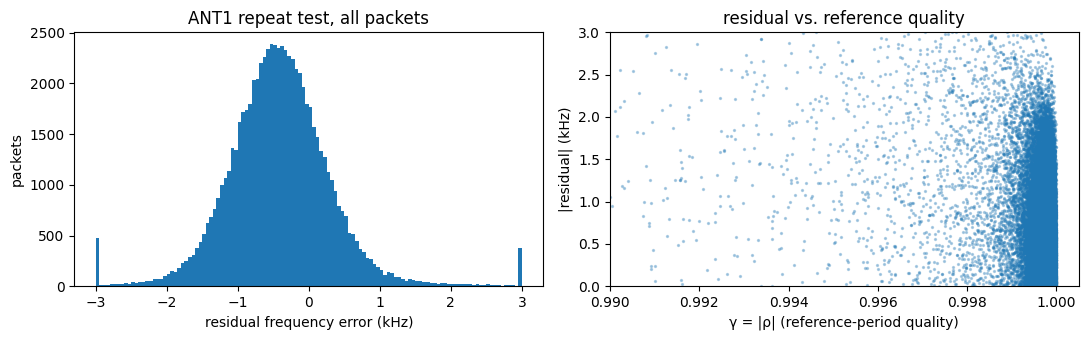

In [12]:
ph_all = np.angle(Zc[:, [k-1 for k in ANT1_SLOTS]])                 # (N, 4)
steps  = np.exp(1j * np.diff(ph_all, axis=1))                         # (N, 3) unit phasors
resid_deg = np.degrees(np.angle(steps.mean(axis=1)))                  # mean step per 32 µs, wrap-safe
df['resid_kHz'] = resid_deg / (360 * 32e-6) / 1e3

print(f"residual CFO error over {len(df)} packets:")
print(f"  mean {df.resid_kHz.mean():+.3f} kHz,  std {df.resid_kHz.std():.3f} kHz,  |resid| < 1 kHz on {(df.resid_kHz.abs() < 1).mean():.1%} of packets")
print(f"  equivalent phase error per 32 µs: std {df.resid_kHz.std()*360*32e-3:.1f}°")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df.resid_kHz.clip(-3, 3), bins=120, color='C0')
ax[0].set_xlabel('residual frequency error (kHz)'); ax[0].set_ylabel('packets'); ax[0].set_title('ANT1 repeat test, all packets')
ax[1].scatter(df.cfo_gamma, df.resid_kHz.abs(), s=2, alpha=0.3)
ax[1].set_xlim(0.99, 1.0005); ax[1].set_ylim(0, 3)
ax[1].set_xlabel('γ = |ρ| (reference-period quality)'); ax[1].set_ylabel('|residual| (kHz)')
ax[1].set_title('residual vs. reference quality')
plt.tight_layout(); plt.show()

Two things to note. The residual is centred near zero with a spread well under 1 kHz, so the map is right (a wrong map would give a broad, structureless distribution) and the correction is doing its job. And the residual is *common to all antennas* within a group — it depends on time, and one group spans only 30 µs (the time gap between the ANT1 sample and the ANT16 sample: 16 samples, hence 15 steps of 2 µs; the sixteen 2 µs slots themselves occupy 32 µs, which is why successive ANT1 visits are 32 µs apart) — so it mostly cancels when each antenna is referenced to ANT1 of the same group. That is why G2, G3, G4 are treated as three separate snapshots rather than one 48-sample block.

**Optional refinement.** Because the true offset changes only slowly (temperature), $\angle\rho$ can be smoothed over neighbouring packets of the same tag (a sliding-window median). Earlier datasets showed this removes ~90% of the per-packet scatter at no loss of packets. It is left out here to keep the basic step clear.

## 6. Building snapshots

One complete sweep gives 16 complex numbers, one per antenna. Two small operations turn them into the vector MUSIC expects:

1. **Order by antenna** using $\mathrm{ant}(k)$, so position $n$ of the vector is ANT$n$.
2. **Reference to ANT1**: $x_n \leftarrow x_n\,\bar x_1/|x_1|$. This removes $\phi_0$ (and most of the residual ramp), leaving $x_n = A_n e^{\,j(\psi_n - \psi_1)}$.

In [13]:
COMPLETE = ['G2', 'G3', 'G4']

def snapshots(Zc):
    """Returns dict group -> (N, 16) complex array, antenna order ANT1..ANT16, referenced to ANT1."""
    out = {}
    for g in COMPLETE:
        ks  = np.array(list(GROUPS[g]))
        idx = np.empty(16, int)
        idx[ANT[ks-1] - 1] = ks - 1          # column index of each antenna
        X = Zc[:, idx]                        # (N, 16) in antenna order
        ref = X[:, [0]]
        out[g] = X * np.conj(ref) / np.abs(ref)
    return out

SNAP = snapshots(Zc)
{g: v.shape for g, v in SNAP.items()}

{'G2': (73000, 16), 'G3': (73000, 16), 'G4': (73000, 16)}

### The three snapshots of the example packet

Phase relative to ANT1 and amplitude, for G2/G3/G4, plus the spread across the groups.

In [14]:
tab = pd.DataFrame(index=pd.Index(range(1, 17), name='ant'))
for g in COMPLETE:
    tab[f'{g} phase'] = np.degrees(np.angle(SNAP[g][p]))
for g in COMPLETE:
    tab[f'{g} amp'] = np.abs(SNAP[g][p])
ph3 = np.radians(tab[[f'{g} phase' for g in COMPLETE]].to_numpy())
dev = np.degrees(np.angle(np.exp(1j*ph3) / np.exp(1j*ph3).mean(1, keepdims=True)))   # each group's deviation from the packet mean
tab.insert(3, 'spread', dev.max(1) - dev.min(1))
tab.round(0).astype(int)

,G2 phase,G3 phase,G4 phase,spread,G2 amp,G3 amp,G4 amp
ant,,,,,,,
1,0,0,0,0,115,114,115
2,-47,-50,-47,3,51,51,53
3,-62,-65,-63,2,85,86,87
4,-55,-56,-55,1,74,75,77
5,12,8,8,3,51,50,51
6,-51,-50,-51,1,49,51,52
7,-46,-46,-47,2,47,47,47
8,-151,-148,-152,5,13,12,12
9,90,89,91,2,41,40,41


Three points from the table:

- After referencing to ANT1 the group-to-group offset from Section 5 is gone: the three columns agree to within a few degrees on almost every antenna. That is the repeatability of a single packet.
- In this packet the weakest antennas (ANT8 ≈ 12, ANT10 ≈ 24) have the largest spreads. Phase noise scales inversely with amplitude, so a low-amplitude sample is a noisy input to MUSIC.
- The amplitudes are far from uniform (≈ 12 to 115). Amplitude on a given antenna is *not* a fixed property of that antenna — it changes from packet to packet with tag position and multipath — so this is a per-packet pattern, not a hardware ranking of the elements.

### Amplitude vs. phase spread across the whole dataset

The relation must be tested per **sample**, not per antenna: averaging amplitude over 73k packets washes out the per-packet fading and every antenna lands near the same mean. So take every (group, packet, antenna) sample, its amplitude and its deviation from the packet's mean phase, and bin by amplitude.

In [15]:
ph  = np.stack([np.angle(SNAP[g]) for g in COMPLETE], axis=0)      # (3, N, 16)
amp = np.stack([np.abs(SNAP[g])   for g in COMPLETE], axis=0)
u   = np.exp(1j*ph)
dev = np.degrees(np.angle(u / u.mean(axis=0, keepdims=True)))      # each group's deviation from the packet mean, (3, N, 16)

a, e = amp[:, :, 1:].reshape(-1), np.abs(dev[:, :, 1:]).reshape(-1)  # drop ANT1 (reference, always 0)
bins = [0, 10, 20, 30, 40, 60, 80, 120, 200, 400]
binned = (pd.DataFrame({'amp': pd.cut(a, bins), 'dev': e})
            .groupby('amp', observed=True)['dev']
            .agg(samples='size', median_deg='median', rms_deg=lambda x: np.sqrt((x**2).mean()))
            .round(2))
binned

,samples,median_deg,rms_deg
amp,,,
"(0, 10]",31282,3.34,13.00
"(10, 20]",80710,1.64,7.52
"(20, 30]",140603,1.20,5.45
"(30, 40]",206395,1.04,4.13
"(40, 60]",567205,0.92,3.03
"(60, 80]",805598,0.84,2.26
"(80, 120]",1353946,0.83,2.18
"(120, 200]",98893,0.83,4.02


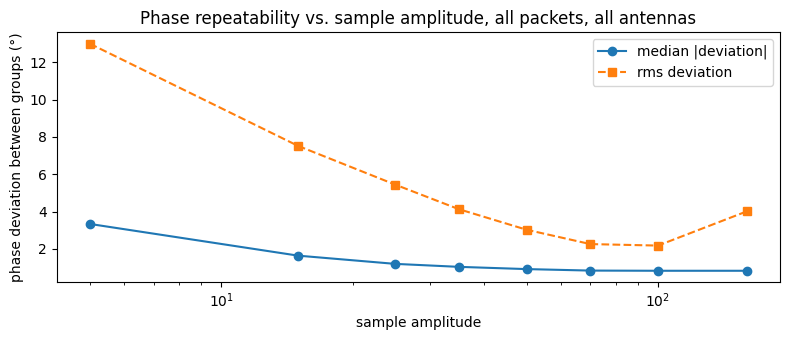

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.5))
centres = [(lo+hi)/2 for lo, hi in zip(bins[:-1], bins[1:])][:len(binned)]
ax.plot(centres, binned['median_deg'], 'o-', label='median |deviation|')
ax.plot(centres, binned['rms_deg'], 's--', label='rms deviation')
ax.set_xscale('log'); ax.set_xlabel('sample amplitude'); ax.set_ylabel('phase deviation between groups (°)')
ax.set_title('Phase repeatability vs. sample amplitude, all packets, all antennas'); ax.legend()
plt.tight_layout(); plt.show()

Median deviation falls from ≈ 3.3° for samples below 10 units to ≈ 0.75° above 80 — the inverse relation holds across the dataset, per sample. Keep this in mind for Step 3: an unweighted covariance treats a 12-unit sample the same as a 115-unit one.

### Per-antenna view

For completeness, the same deviation summarised per antenna. Median is used rather than rms: rms is dominated by a small tail of bad packets and can make one antenna look noisy when its typical behaviour is identical to the others.

In [17]:
per_ant = pd.DataFrame({
    'median_dev_deg': np.median(np.abs(dev), axis=(0, 1)),
    'p90_dev_deg':    np.percentile(np.abs(dev), 90, axis=(0, 1)),
    'p99_dev_deg':    np.percentile(np.abs(dev), 99, axis=(0, 1)),
    'mean_amp':       amp.mean(axis=(0, 1)),
}, index=pd.Index(range(1, 17), name='ant')).round(1)
per_ant.T

ant,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
median_dev_deg,0.0,0.9,0.8,0.9,0.8,0.9,0.9,0.9,0.9,0.9,1.0,0.9,0.9,0.9,0.9,0.9
p90_dev_deg,0.0,2.3,2.2,2.3,2.2,2.5,2.5,2.4,2.3,2.5,2.6,2.4,2.3,2.4,2.5,2.5
p99_dev_deg,0.0,7.6,6.6,6.8,7.3,8.5,13.3,8.3,7.9,8.7,10.1,8.0,6.6,8.5,7.8,7.4
mean_amp,90.3,74.3,73.6,79.8,76.7,74.0,69.2,72.3,77.3,68.2,64.9,69.8,83.0,75.6,67.9,78.1


Every antenna sits at the same median (≈ 0.9°) and 90th percentile (≈ 2.5°); differences only appear in the 99th percentile, i.e. in how many outlier packets each antenna collects. Mean amplitude is nearly flat across antennas (65–90), confirming that the 12-to-115 range in the single-packet table was that packet's fading pattern, not the array's.

## 7. Save

Store the three snapshot arrays with the packet metadata so Step 3 can start from here without recomputing.

In [18]:
import pickle
meta = df[['set', 'pt', 'address', 'sequence', 'channel', 'rssi', 'timestamp', 'cfo_kHz', 'cfo_gamma', 'resid_kHz']].reset_index(drop=True)
with open('dataset19_snapshots.pkl', 'wb') as f:
    pickle.dump({'meta': meta, 'snap': SNAP, 'groups': COMPLETE,
                 'note': 'snap[g]: (N,16) complex, ANT1..16, CFO-removed, referenced to ANT1'}, f)
print('wrote dataset19_snapshots.pkl:', {g: v.shape for g, v in SNAP.items()})

wrote dataset19_snapshots.pkl: {'G2': (73000, 16), 'G3': (73000, 16), 'G4': (73000, 16)}


## Summary

- Every switched sample carries a phase $2\pi\Delta f\,t_k$ set by its sampling time — about −148° per 2 µs switch, larger than any spatial phase.
- Multiplying sample $k$ by $\bar\rho^{\,t_k/T_s}$ removes it; amplitudes are unchanged.
- The repeated-antenna test (ANT1 at IQ24/40/56/72) confirms both the antenna map and the correction; its residual is the error of the 8-sample CFO estimate, ≈ 0.5 kHz, and is common-mode within a group.
- Ordering by antenna and referencing to ANT1 turns each of G2, G3, G4 into a 16-element snapshot; the three agree to a few degrees per packet, worst on the weakest antennas.

**Next (Step 3):** sliding windows of N packets → 3N snapshots → covariance $R = X X^H$ → four-way steering-vector sign test on the reference tags → MUSIC.